# Rekomendasi Games

## Import Libraries

In [46]:
import pandas as pd
import numpy as np
import re
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

## Data Loading & Preprocessing

In [47]:
# 1. Load Data
# Menggunakan encoding='latin1' untuk menghindari UnicodeDecodeError pada metadata
df_meta = pd.read_csv('data/games_data.csv', encoding='latin1') 
df_inter = pd.read_csv('data/steam-200k.csv', header=None, 
                       names=['user_id', 'game_title', 'behavior', 'value', 'zero'])

# 2. Buang Kolom Tidak Relevan
# Drop kolom teks panjang dan metrik review yang tidak dibutuhkan untuk model XGBoost
cols_to_drop = ['id', 'dc_price', 'overall_review', 'detailed_review', 'reviews']
df_meta = df_meta.drop(columns=[c for c in cols_to_drop if c in df_meta.columns])
df_inter = df_inter.drop(columns=['zero'])

# 3. Standardisasi Judul Game
def clean_title(title):
    if pd.isna(title): return ""
    title = title.lower()
    # Hapus simbol spesial yang sering membuat proses merge gagal
    title = re.sub(r'[™®©]', '', title) 
    return title.strip()

df_meta['clean_title'] = df_meta['title'].apply(clean_title)
df_inter['clean_title'] = df_inter['game_title'].apply(clean_title)

# 4. Filter Interaksi
# Hanya menyimpan data interaksi user pada game yang profilnya tersedia di metadata
valid_games = set(df_meta['clean_title']).intersection(set(df_inter['clean_title']))
df_inter_filtered = df_inter[df_inter['clean_title'].isin(valid_games)].copy()

print(f"Data Metadata awal: {df_meta.shape}")
print(f"Data Interaksi awal: {df_inter.shape}")
print(f"Data Interaksi setelah difilter (siap pakai): {df_inter_filtered.shape}")

C:\Users\THIN 15\AppData\Local\Temp\ipykernel_32696\1401733789.py:3: DtypeWarning: Columns (10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv('data/games_data.csv', encoding='latin1')


Data Metadata awal: (73344, 12)
Data Interaksi awal: (200000, 5)
Data Interaksi setelah difilter (siap pakai): (96753, 5)


## Target & Negative Sampling

In [48]:
# Cell 3: Pembuatan Target & Negative Sampling

# --- 1. HANDLING KELAS 1 (INTERAKSI POSITIF) ---
# Ambil user_id dan judul game dari data yang sudah difilter
df_positive = df_inter_filtered[['user_id', 'clean_title']].copy()

# Hapus duplikat (menggabungkan baris 'purchase' dan 'play' menjadi satu kesatuan interaksi)
df_positive = df_positive.drop_duplicates()
df_positive['target'] = 1

# --- 2. NEGATIVE SAMPLING (PEMBUATAN KELAS 0) ---
# Ambil daftar unik user dan game dari dataset yang valid
unique_users = df_positive['user_id'].unique()
unique_games = list(valid_games)

# Tentukan jumlah sampel negatif (sama dengan jumlah positif agar balance 50:50)
num_positives = len(df_positive)

# Set seed agar hasil randomisasi selalu konsisten setiap kali cell di-run ulang
np.random.seed(42)

# Generate kombinasi acak user dan game
neg_users = np.random.choice(unique_users, size=num_positives)
neg_games = np.random.choice(unique_games, size=num_positives)

df_negative = pd.DataFrame({'user_id': neg_users, 'clean_title': neg_games})
df_negative['target'] = 0

# Validasi: Pastikan sampel negatif bukan game yang sebenarnya sudah dimainkan user
df_negative_check = pd.merge(df_negative, df_positive[['user_id', 'clean_title']], 
                             on=['user_id', 'clean_title'], 
                             how='left', indicator=True)

# Hanya ambil data yang ada di df_negative tapi TIDAK ADA di df_positive ('left_only')
df_negative_clean = df_negative_check[df_negative_check['_merge'] == 'left_only'].drop(columns=['_merge'])

# (Opsional) Mengisi kekurangan baris akibat proses validasi di atas agar jumlahnya kembali seimbang
kekurangan = num_positives - len(df_negative_clean)
if kekurangan > 0:
    tambahan_users = np.random.choice(unique_users, size=kekurangan)
    tambahan_games = np.random.choice(unique_games, size=kekurangan)
    df_tambahan = pd.DataFrame({'user_id': tambahan_users, 'clean_title': tambahan_games, 'target': 0})
    df_negative_clean = pd.concat([df_negative_clean, df_tambahan], ignore_index=True)

# --- 3. GABUNGKAN DATA FINAL ---
df_interactions_final = pd.concat([df_positive, df_negative_clean], ignore_index=True)

# Acak urutan barisnya agar tidak menumpuk (kelas 1 di atas, kelas 0 di bawah)
df_interactions_final = df_interactions_final.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribusi Kelas pada Target Dataset:")
print(df_interactions_final['target'].value_counts())
print(f"Total baris riwayat interaksi siap gabung: {len(df_interactions_final)}")

Distribusi Kelas pada Target Dataset:
target
0    58794
1    58794
Name: count, dtype: int64
Total baris riwayat interaksi siap gabung: 117588


## Data Merge & Feature Engineering

In [49]:
# Cell 4: Penggabungan Data & Feature Engineering (REVISI NON-NSFW)

# --- 1. PENGGABUNGAN DATA (MERGE) ---
df_merged = pd.merge(df_interactions_final, df_meta, on='clean_title', how='inner')

# --- 2. FEATURE ENGINEERING: PEMBERSIHAN DATA NUMERIK ---
def clean_price(val):
    if pd.isna(val): return 0.0
    val = str(val).lower().strip()
    if 'free' in val or 'play' in val: return 0.0
    val = re.sub(r'[^\d.]', '', val)
    return float(val) if val != '' else 0.0

if 'price' in df_merged.columns:
    df_merged['price_num'] = df_merged['price'].apply(clean_price)

if 'percent_positive' in df_merged.columns:
    df_merged['percent_positive_num'] = df_merged['percent_positive'].astype(str).str.replace('%', '', regex=False)
    df_merged['percent_positive_num'] = pd.to_numeric(df_merged['percent_positive_num'], errors='coerce').fillna(0)

# --- 3. FEATURE ENGINEERING: ONE-HOT ENCODING ---
df_merged['genres'] = df_merged['genres'].fillna('Unknown')
df_merged['multiplayer_or_singleplayer'] = df_merged['multiplayer_or_singleplayer'].fillna('Unknown')

genres_dummies = df_merged['genres'].str.get_dummies(sep=';').add_prefix('genre_')
mode_dummies = df_merged['multiplayer_or_singleplayer'].str.get_dummies(sep=';').add_prefix('mode_')

df_model_ready = pd.concat([df_merged, genres_dummies, mode_dummies], axis=1)

# --- 4. FILTER GENRE NSFW (BARU) ---
nsfw_cols = ['genre_Nudity', 'genre_Sexual Content']
df_model_ready = df_model_ready.drop(columns=[c for c in nsfw_cols if c in df_model_ready.columns])
print(f"Kolom NSFW berhasil dihapus: {nsfw_cols}")

# --- 5. PEMBUANGAN KOLOM STRING/KATEGORIKAL ---
cols_to_drop_final = ['title', 'developer', 'publisher', 'genres', 'multiplayer_or_singleplayer', 
                      'price', 'percent_positive', 'release_date', 'behavior', 'value']

df_model_ready = df_model_ready.drop(columns=[c for c in cols_to_drop_final if c in df_model_ready.columns])

print(f"Ukuran Data setelah Feature Engineering: {df_model_ready.shape}")

Kolom NSFW berhasil dihapus: ['genre_Nudity', 'genre_Sexual Content']
Ukuran Data setelah Feature Engineering: (124113, 51)


## Data Splitting

In [50]:
# 1. Definisikan Fitur (X) dan Target (y)
cols_to_exclude = ['user_id', 'clean_title', 'target']
X = df_model_ready.drop(columns=[c for c in cols_to_exclude if c in df_model_ready.columns])

# --- FIX ERROR XGBOOST ---
# Memaksa seluruh kolom fitur di X menjadi tipe numerik (float/int). 
# Parameter errors='coerce' akan mengubah teks nyasar menjadi NaN agar bisa ditelan XGBoost.
X = X.apply(pd.to_numeric, errors='coerce')
# -------------------------

y = df_model_ready['target']

# 2. Membagi Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("=== Ringkasan Pembagian Data ===")
print(f"Total dimensi X_train (Fitur Latih) : {X_train.shape}")
print(f"Total dimensi y_train (Target Latih): {y_train.shape}")
print(f"Total dimensi X_test  (Fitur Uji)   : {X_test.shape}")
print(f"Total dimensi y_test  (Target Uji)  : {y_test.shape}")
print("\nPengecekan Tipe Data (Harus Numerik Semua):")
print(X_train.dtypes.value_counts())

=== Ringkasan Pembagian Data ===
Total dimensi X_train (Fitur Latih) : (99290, 48)
Total dimensi y_train (Target Latih): (99290,)
Total dimensi X_test  (Fitur Uji)   : (24823, 48)
Total dimensi y_test  (Target Uji)  : (24823,)

Pengecekan Tipe Data (Harus Numerik Semua):
int64      43
float64     5
Name: count, dtype: int64


## Model Training

In [51]:
# Cell 6: Model Training (XGBoost)

# 1. Inisialisasi Model XGBoost
# Menggunakan parameter standar yang terbukti ampuh untuk klasifikasi biner
xgb_model = XGBClassifier(
    n_estimators=100,        # Jumlah pohon keputusan yang akan dibuat
    max_depth=6,             # Kedalaman maksimal setiap pohon (mencegah model terlalu kompleks)
    learning_rate=0.1,       # Seberapa cepat model belajar dari kesalahan sebelumnya
    random_state=42,         # Agar hasil akurasi tetap konsisten setiap kali di-run
    eval_metric='logloss'    # Metrik evaluasi internal untuk klasifikasi
)

# 2. Melatih Model (Training Process)
print("Memulai proses training model XGBoost...")

# eval_set digunakan agar kita bisa melihat pergerakan performa saat proses belajar
xgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=10  # Menampilkan log progress setiap 10 iterasi (pohon)
)

print("\nProses training selesai!")

Memulai proses training model XGBoost...
[0]	validation_0-logloss:0.66373	validation_1-logloss:0.66381
[10]	validation_0-logloss:0.53521	validation_1-logloss:0.53629
[20]	validation_0-logloss:0.49686	validation_1-logloss:0.49926
[30]	validation_0-logloss:0.47961	validation_1-logloss:0.48356
[40]	validation_0-logloss:0.46981	validation_1-logloss:0.47474
[50]	validation_0-logloss:0.46235	validation_1-logloss:0.46784
[60]	validation_0-logloss:0.45584	validation_1-logloss:0.46220
[70]	validation_0-logloss:0.45153	validation_1-logloss:0.45828
[80]	validation_0-logloss:0.44563	validation_1-logloss:0.45296
[90]	validation_0-logloss:0.44170	validation_1-logloss:0.44940
[99]	validation_0-logloss:0.43748	validation_1-logloss:0.44552

Proses training selesai!


## Model Evaluation

=== Hasil Evaluasi Model XGBoost ===
Accuracy Score : 0.7975 (79.75%)
ROC-AUC Score  : 0.8709

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81     12431
           1       0.85      0.72      0.78     12392

    accuracy                           0.80     24823
   macro avg       0.80      0.80      0.80     24823
weighted avg       0.80      0.80      0.80     24823



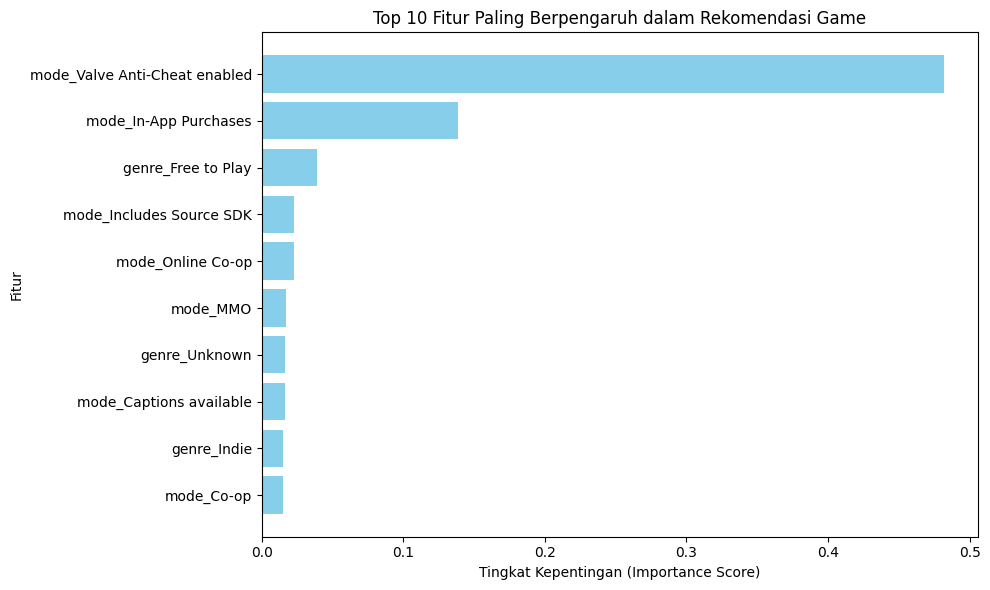

In [52]:
# 1. Melakukan Prediksi
# y_pred untuk menebak kelas (0 atau 1)
y_pred = xgb_model.predict(X_test)

# y_pred_proba untuk mengambil nilai probabilitas (0.0 hingga 1.0)
# Nilai inilah yang nanti kita jadikan "Persentase Match" di dashboard Streamlit
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 2. Menghitung Metrik
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Hasil Evaluasi Model XGBoost ===")
print(f"Accuracy Score : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC Score  : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 3. Visualisasi Top 10 Feature Importance
# Mengambil skor bobot (importance) dari setiap fitur/kolom
importances = xgb_model.feature_importances_
feature_names = X_train.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
# [::-1] digunakan agar bar chart berurutan dari yang terbesar di atas
plt.barh(feature_imp_df['Feature'][::-1], feature_imp_df['Importance'][::-1], color='skyblue')
plt.title('Top 10 Fitur Paling Berpengaruh dalam Rekomendasi Game')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

## Export Model

In [53]:
# 1. Pastikan folder backend/models/ ada
os.makedirs('backend/models', exist_ok=True)

# 2. Menyimpan Model XGBoost
with open('backend/models/xgboost_recsys.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# 3. Membuat Katalog Game untuk Backend
df_katalog = X.copy()
df_katalog['clean_title'] = df_model_ready['clean_title']
df_katalog['title'] = df_merged['title']

df_katalog = df_katalog.drop_duplicates(subset=['clean_title']).reset_index(drop=True)

# 4. Menyimpan Katalog ke folder backend
df_katalog.to_pickle('backend/models/game_features.pkl')
df_katalog[['clean_title', 'title']].to_csv('backend/models/clean_game_catalog.csv', index=False)

print("Semua file berhasil disimpan ke folder backend/models/!")

Semua file berhasil disimpan ke folder backend/models/!
